### Exp 3: Implementation of Simple Linear Regression Model Using Gradient descent

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


Load and Display the Dataset


In [13]:
# Load dataset
data = pd.read_csv("C:\\Users\\ksvin\\Downloads\\exp_3_50_Startups.csv")

# Display first few rows
print("First 5 rows of the dataset:")
display(data.head())


First 5 rows of the dataset:


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


Handle Categorical Data (State Column)

The dataset has a categorical feature State.
We convert it into numeric dummy variables using one-hot encoding.


In [14]:
# One-hot encode the 'State' column
data_encoded = pd.get_dummies(data, columns=['State'], drop_first=True)

# Display the encoded dataset
print("Encoded dataset:")
display(data_encoded.head())


Encoded dataset:


,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


Separate Features and Target


In [15]:
# Independent features (all columns except Profit)
X_raw = data_encoded.drop('Profit', axis=1).values

# Target variable (Profit)
y_raw = data_encoded['Profit'].values.reshape(-1, 1)

print("Shape of features:", X_raw.shape)
print("Shape of target:", y_raw.shape)


Shape of features: (50, 5)
Shape of target: (50, 1)


Feature Scaling

To ensure faster and stable convergence during gradient descent, we scale both features and the target using StandardScaler.


In [16]:
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X = X_scaler.fit_transform(X_raw)
y = y_scaler.fit_transform(y_raw)


In [17]:
# Add a column of ones to X for bias term
m = X.shape[0]
X = np.hstack((np.ones((m, 1)), X))
print("Shape of X after adding bias term:", X.shape)


Shape of X after adding bias term: (50, 6)


In [18]:
def compute_cost(X, y, theta):
    """
    Compute Mean Squared Error cost.
    """
    m = len(y)
    preds = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum((preds - y) ** 2)
    return cost


In [19]:
def gradient_descent(X, y, learning_rate=0.01, num_iters=2000, tol=1e-8, verbose=False):
    """
    Batch Gradient Descent for Linear Regression.
    """
    m, n = X.shape
    theta = np.zeros((n, 1))
    J_history = []

    prev_cost = compute_cost(X, y, theta)

    for i in range(num_iters):
        preds = X.dot(theta)
        errors = preds - y
        grad = (1 / m) * (X.T.dot(errors))
        theta -= learning_rate * grad

        cost = compute_cost(X, y, theta)
        J_history.append(cost)

        if abs(prev_cost - cost) < tol:
            if verbose:
                print(f"Converged at iteration {i}")
            break
        prev_cost = cost

        if verbose and (i % 500 == 0 or i < 5):
            print(f"Iteration {i:4d}, Cost: {cost:.6f}")

    return theta, J_history


Train the Model

In [20]:
alpha = 0.01
theta, J_hist = gradient_descent(X, y, learning_rate=alpha, num_iters=5000, tol=1e-9, verbose=True)

print("\nLearned Parameters (Theta):")
print(theta.flatten())


Iteration    0, Cost: 0.484533
Iteration    1, Cost: 0.469608
Iteration    2, Cost: 0.455204
Iteration    3, Cost: 0.441305
Iteration    4, Cost: 0.427891
Iteration  500, Cost: 0.028780
Iteration 1000, Cost: 0.025079
Iteration 1500, Cost: 0.024674
Iteration 2000, Cost: 0.024629
Iteration 2500, Cost: 0.024624
Converged at iteration 2724

Learned Parameters (Theta):
[-4.45465886e-16  9.16940263e-01 -1.84227160e-02  8.28232243e-02
  2.20954386e-03 -4.80500983e-04]


Plot Cost vs Iterations

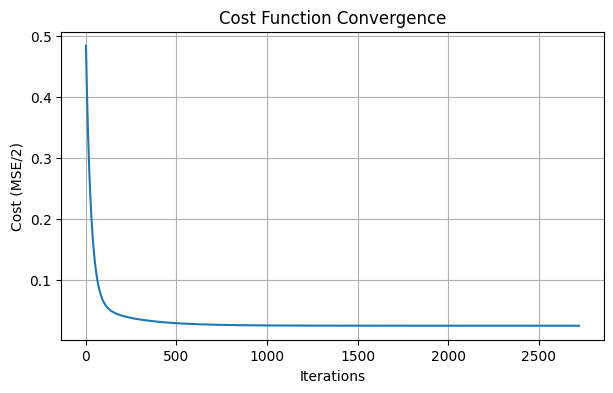

In [21]:
plt.figure(figsize=(7,4))
plt.plot(J_hist)
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE/2)')
plt.title('Cost Function Convergence')
plt.grid(True)
plt.show()


In [22]:
# Create new sample (same feature names as original)
new_sample = pd.DataFrame([{
    'R&D Spend': 165349.2,
    'Administration': 136897.8,
    'Marketing Spend': 471784.1,
    'State': 'New York'
}])

# Apply one-hot encoding
new_encoded = pd.get_dummies(new_sample, columns=['State'], drop_first=True)

# Align columns with training data (add missing ones as 0)
new_encoded = new_encoded.reindex(columns=data_encoded.drop('Profit', axis=1).columns, fill_value=0)

# Scale new data
new_scaled = X_scaler.transform(new_encoded)

# Add bias
new_design = np.hstack((np.ones((new_scaled.shape[0], 1)), new_scaled))

# Predict (scaled)
scaled_pred = new_design.dot(theta)

# Inverse transform to original units
pred_original = y_scaler.inverse_transform(scaled_pred)

print(f"\nPredicted Profit for the new startup: ₹{pred_original[0][0]:,.2f}")



Predicted Profit for the new startup: ₹192,446.20


C:\Users\ksvin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
